In [12]:
import yaml
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import yaml
import os.path as op
import scanpy as sc
import numpy as np
import pandas as pd




In [13]:
final_metrics = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/comparison_NM_SC_GB.tsv', sep = '\t', header=0)

In [14]:
all_times = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/runtime_data.tsv', sep = '\t', header=0)

In [15]:
auc = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/auc_benchmark.csv', header=0, sep = ';')
auc

,Method,Case 1,Case 2,Case 3
0,LINGER,0.76,0.71,0.70
1,scPRINT,NaN,0.56,0.53
2,GRNBoost2,0.56,0.51,0.58
3,NetMap_noD,0.60,0.64,0.74
4,NetMap_noD(Abs),0.54,0.61,0.73
5,NetMap_D,0.56,0.63,0.42
6,NetMap_D(Abs),0.51,0.62,0.42


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
auc

# Reshape wide -> long: one row per (Method, Case, AUC)


,Method,Case 1,Case 2,Case 3
0,LINGER,0.76,0.71,0.70
1,scPRINT,NaN,0.56,0.53
2,GRNBoost2,0.56,0.51,0.58
3,NetMap_noD,0.60,0.64,0.74
4,NetMap_noD(Abs),0.54,0.61,0.73
5,NetMap_D,0.56,0.63,0.42
6,NetMap_D(Abs),0.51,0.62,0.42


In [17]:
auc = auc[auc.Method.isin(['LINGER', 'scPRINT', 'GRNBoost2', 'NetMap_noD'])].copy()
auc["Method"] = auc["Method"].replace("NetMap_noD", "Netmap")
auc_long = auc.melt(id_vars="Method", var_name="Case", value_name="AUC")
auc

,Method,Case 1,Case 2,Case 3
0,LINGER,0.76,0.71,0.70
1,scPRINT,NaN,0.56,0.53
2,GRNBoost2,0.56,0.51,0.58
3,Netmap,0.60,0.64,0.74


In [18]:
final_metrics["algorithm"] = final_metrics["algorithm"].replace({
    "netmap": "Netmap",
    "scgenerai": "scGeneRAI",
    "grnboost2": "GRNBoost2",
})

In [19]:
all_times

,Unnamed: 0,time_elapsed_total,time_elapsed,net,config,root_config,method,runtime_minutes,total_time,n_clusters
0,0,56.753578,56.351954,net_53_11196_net_70_11431_net_84_9903,config_easy,grnboost2,final_benchmark,0.945893,NaN,2
1,1,70.564107,70.250151,net_133_10773_net_82_10152_net_72_10551,config_easy,grnboost2,final_benchmark,1.176068,NaN,2
2,2,85.381584,84.936312,net_172_10626_net_89_11634_net_76_10367,config_easy,grnboost2,final_benchmark,1.423026,NaN,2
3,3,61.669205,61.231676,net_59_10488_net_115_11153_net_84_11226,config_easy,grnboost2,final_benchmark,1.027820,NaN,2
4,4,68.955128,68.638371,net_60_10082_net_64_11307_net_84_11226,config_easy,grnboost2,final_benchmark,1.149252,NaN,2
...,...,...,...,...,...,...,...,...,...,...
130,31,13800.018463,13118.077942,net_141_11706_net_81_10586_net_115_11153_net_5...,config_three_noise,scgenerai,final_benchmark,230.000308,NaN,3
131,32,11535.122295,11124.021072,net_60_10082_net_64_11307_net_84_11226_net_133...,config_three_noise,scgenerai,final_benchmark,192.252038,NaN,3
132,33,10535.005588,9880.984606,net_60_10082_net_90_11013_net_75_10306_net_77_...,config_three_noise,scgenerai,final_benchmark,175.583426,NaN,3
133,34,10699.988368,10311.719065,net_70_11431_net_60_10082_net_135_11054_net_53...,config_three_noise,scgenerai,final_benchmark,178.333139,NaN,3


In [20]:
all_times["algorithm"] = all_times["root_config"].replace({
    "netmap": "Netmap",
    "scgenerai": "scGeneRAI",
    "grnboost2": "GRNBoost2",
})

In [40]:
# ---------------------------------------------------------------
algorithms = sorted(final_metrics["algorithm"].unique())
methods = sorted(auc["Method"].unique())

# Union of both label sets, so any name shared between the two
final_metrics["target_hr"] = final_metrics["target"].replace({
    "on_target": "On-target",
    "off_target": "Off-target",
    "grnboost2": "GRNBoost2",
})

/tmp/ipykernel_1031241/3123414101.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


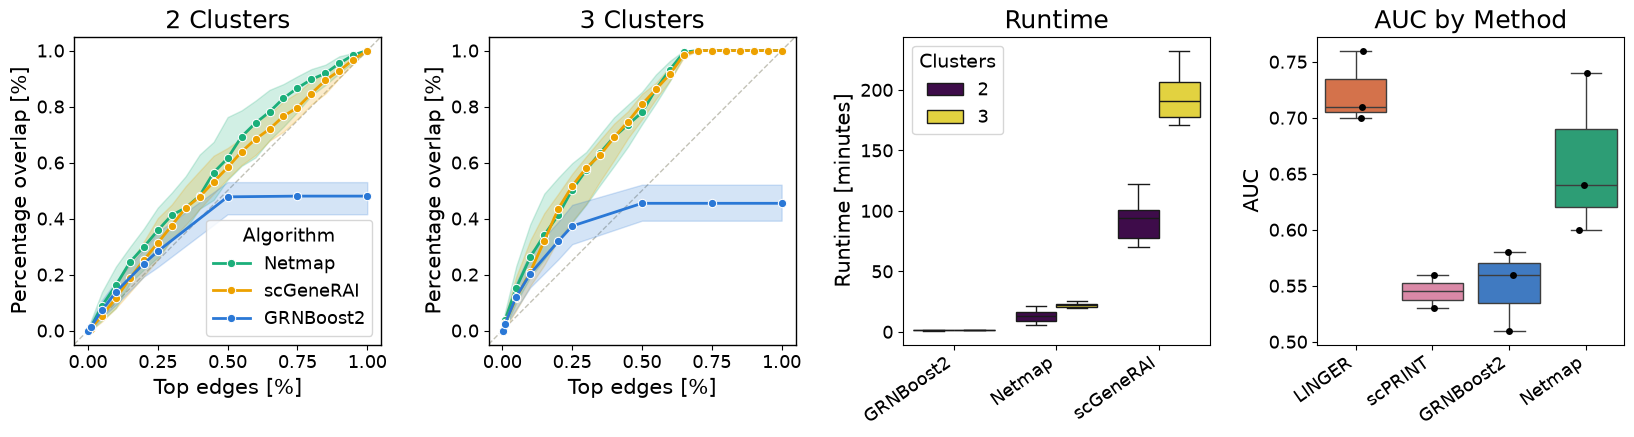

In [36]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

# --- Global font sizing for A4 legibility ---
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
    "figure.titlesize": 20,
})

CATEGORICAL_PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
]

# ---------------------------------------------------------------
# Unified palette across panels 1, 2, and 4
# ---------------------------------------------------------------
all_labels = sorted(set(algorithms) | set(methods))
palette = dict(zip(all_labels, CATEGORICAL_PALETTE * (len(all_labels) // len(CATEGORICAL_PALETTE) + 1)))

fig = plt.figure(figsize=(20, 4))
gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

n_clusters_values = [2, 3]
target_for_line_plot = final_metrics["target_hr"].unique()[0]

line_axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]

for ax, n_clusters in zip(line_axes, n_clusters_values):
    sub = final_metrics[
        (final_metrics["target_hr"] == target_for_line_plot)
        & (final_metrics["n_clusters"] == n_clusters)
    ]
    sns.lineplot(
        data=sub,
        x="n_top",
        y="percentage_overlap",
        hue="algorithm",
        palette=palette,
        marker="o",
        linewidth=2,
        markersize=6,
        estimator="median",
        errorbar=("pi", 50),
        ax=ax,
        legend=(ax is line_axes[0]),
    )
    ax.set_title(f"{n_clusters} Clusters")
    ax.set_xlabel("Top edges [%]")
    ax.set_ylabel("Percentage overlap [%]")
    ax.grid(False)
    sns.despine(ax=ax, left=False, bottom=False)

    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    lo, hi = xlim
    ax.plot([lo, hi], [lo, hi], color="#c3c2b7", linestyle="--", linewidth=1, zorder=0)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1)

line_axes[0].legend(title="Algorithm")

# ---------------------------------------------------------------
# Panel 3: runtime boxplot
# ---------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
sns.boxplot(
    data=all_times[all_times.n_clusters.isin([2, 3])],
    x="algorithm",
    y="runtime_minutes",
    hue="n_clusters",
    palette="viridis",
    showfliers=False,
    ax=ax3,
)
ax3.set_title("Runtime")
ax3.set_ylabel("Runtime [minutes]")
ax3.set_xlabel("")
ax3.tick_params(axis="x", rotation=35)
for label in ax3.get_xticklabels():
    label.set_ha("right")
ax3.legend(title="Clusters")

# ---------------------------------------------------------------
# Panel 4: AUC boxplot by Method
# ---------------------------------------------------------------
ax4 = fig.add_subplot(gs[0, 3])
sns.boxplot(
    data=auc_long,
    x="Method",
    y="AUC",
    hue="Method",
    showfliers=False,
    ax=ax4,
    palette=palette,
)
sns.stripplot(
    data=auc_long,
    x="Method",
    y="AUC",
    color="black",
    size=5,
    jitter=True,
    ax=ax4,
)
ax4.set_xlabel("")
ax4.set_title("AUC by Method")
ax4.tick_params(axis="x", rotation=35)
for label in ax4.get_xticklabels():
    label.set_ha("right")

fig.tight_layout()

fig.savefig(
    '/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/figure2.pdf',
    dpi=200, bbox_inches="tight"
)
plt.show()

In [46]:
import string

/tmp/ipykernel_1031241/1853913377.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


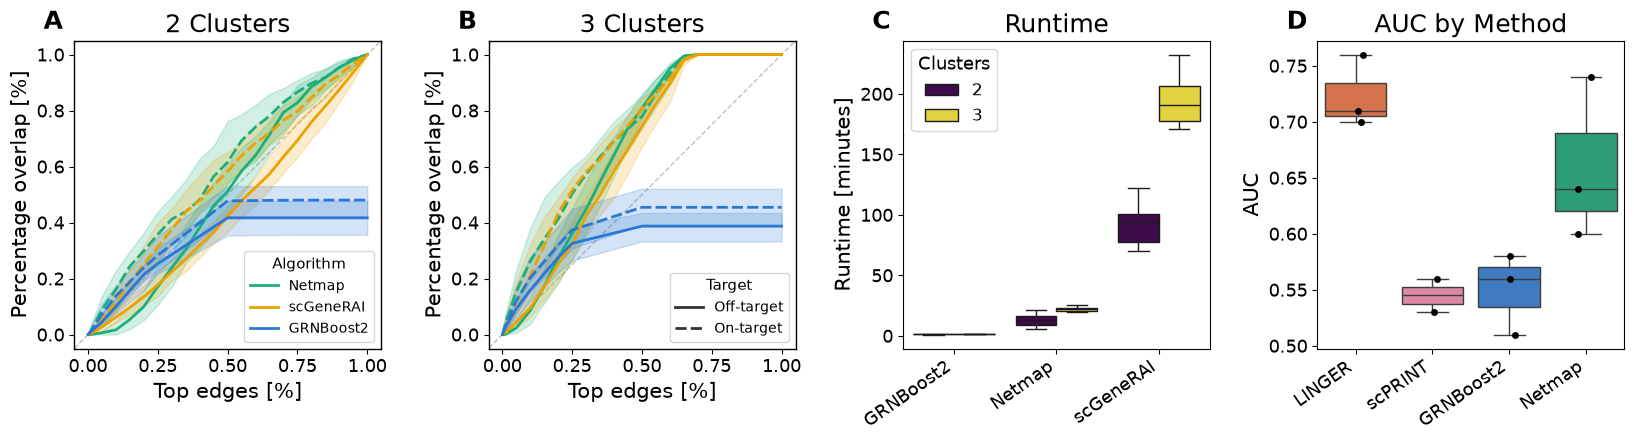

In [56]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

# --- Global font sizing ---
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
})

CATEGORICAL_PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
]

# ---------------------------------------------------------------
# Unified palette across panels 1, 2, and 4
# ---------------------------------------------------------------
all_labels = sorted(set(algorithms) | set(methods))
palette = dict(zip(all_labels, CATEGORICAL_PALETTE * (len(all_labels) // len(CATEGORICAL_PALETTE) + 1)))

fig = plt.figure(figsize=(20, 4))
gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

# ---------------------------------------------------------------
# Panel 1+2: algorithm (color) x target (linestyle), split by n_clusters
# ---------------------------------------------------------------
target_values = sorted(final_metrics["target_hr"].unique())
n_clusters_values = [2, 3]
assert len(target_values) == 2, "Expected exactly 2 target values"

line_axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]

lal = {2: 'A', 3: 'B'}

for ax, n_clusters in zip(line_axes, n_clusters_values):
    sub = final_metrics[final_metrics["n_clusters"] == n_clusters]

    sns.lineplot(
        data=sub,
        x="n_top",
        y="percentage_overlap",
        hue="algorithm",
        style="target_hr",
        style_order=target_values,
        palette=palette,
        #markers=True,
        dashes=True,
        linewidth=2,
        markersize=6,
        estimator="median",
        errorbar=("pi", 50),
        ax=ax,
        legend=(ax is line_axes[0]),
    )

    ax.set_title(f"{n_clusters} Clusters")
    ax.set_xlabel("Top edges [%]")
    ax.set_ylabel("Percentage overlap [%]")
    ax.grid(False)
    sns.despine(ax=ax, left=False, bottom=False)

    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    lo, hi = xlim
    ax.plot([lo, hi], [lo, hi], color="#c3c2b7", linestyle="--", linewidth=1, zorder=0)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1)
    ax.text(
        -0.10, 1.10, lal[n_clusters],
        transform=ax.transAxes,
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left',
    )

# ---------------------------------------------------------------
# Legend split: Algorithm -> panel 1, Target -> panel 2
# ---------------------------------------------------------------
handles, labels = line_axes[0].get_legend_handles_labels()
line_axes[0].get_legend().remove()

# DEBUG: uncomment to inspect raw structure if the split below looks wrong
# print(f"Total entries: {len(handles)}")
# for i, (h, l) in enumerate(zip(handles, labels)):
#     print(f"{i:2d}  label={l!r:30s}  handle_type={type(h).__name__}")

algo_handles, algo_labels = [], []
target_handles, target_labels = [], []
mode = None
for h, l in zip(handles, labels):
    if l == "algorithm":
        mode = "algo"
        continue
    if l == "target_hr":
        mode = "target_hr"
        continue
    if mode == "algo":
        algo_handles.append(h)
        algo_labels.append(l)
    elif mode == "target_hr":
        target_handles.append(h)
        target_labels.append(l)

leg1 = line_axes[0].legend(
    algo_handles, algo_labels, title="Algorithm",
    loc="lower right", frameon=True, fontsize=10, title_fontsize=11,
)

leg2 = line_axes[1].legend(
    target_handles, target_labels, title="Target",
    loc="lower right", frameon=True, fontsize=10, title_fontsize=11,
)

# ---------------------------------------------------------------
# Panel 3: runtime boxplot
# ---------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
sns.boxplot(
    data=all_times[all_times.n_clusters.isin([2, 3])],
    x="algorithm",
    y="runtime_minutes",
    hue="n_clusters",
    palette="viridis",
    showfliers=False,
    ax=ax3,
)
ax3.set_title("Runtime")
ax3.set_ylabel("Runtime [minutes]")
ax3.set_xlabel("")
ax3.tick_params(axis="x", rotation=35)
for label in ax3.get_xticklabels():
    label.set_ha("right")
ax3.legend(title="Clusters")
ax3.text(
        -0.10, 1.10, 'C',
        transform=ax3.transAxes,
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left',
    )
# ---------------------------------------------------------------
# Panel 4: AUC boxplot by Method
# ---------------------------------------------------------------
ax4 = fig.add_subplot(gs[0, 3])
sns.boxplot(
    data=auc_long,
    x="Method",
    y="AUC",
    hue="Method",
    showfliers=False,
    ax=ax4,
    palette=palette,
)
sns.stripplot(
    data=auc_long,
    x="Method",
    y="AUC",
    color="black",
    size=5,
    jitter=True,
    ax=ax4,
)
ax4.set_xlabel("")
ax4.set_title("AUC by Method")
ax4.tick_params(axis="x", rotation=35)
ax4.text(
        -0.10, 1.10, 'D',
        transform=ax4.transAxes,
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left',
    )
for label in ax4.get_xticklabels():
    label.set_ha("right")




fig.tight_layout()
fig.savefig(
    '/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/figure2.pdf',
    dpi=200, bbox_inches="tight"
)
plt.show()